In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import scipy
import numpy as np

from pathlib import Path
import soundfile as sf

In [2]:
SAMPLERATE = 250000
PATH_TO_READ_FILES = Path('/Volumes/Untitled')
FILE_NAME = 'hour_0.raw'
FILEPATH = PATH_TO_READ_FILES / FILE_NAME
PATH_TO_SAVE_WAV_FILES = Path('/Volumes/Elements/UBNA_array_tests2025/mic_array_test_20250422/inHHlab')
NUM_CHANNELS = 8
BYTES_PER_SAMPLE = 2 #int16

WRITE_OFFSET = 0
WRITE_DURATION = 3600

In [3]:
def collect_channels(filepath, samplingrate, offset, duration_in_secs):
    channels = [[], [], [], [], [], [], [], []]

    with open(filepath, "rb") as rawFile:

        rawFile.seek(int(2*8*samplingrate*offset), 0)
        for i in range(samplingrate*duration_in_secs):
            for j in range(8):
                bytes = rawFile.read(2)
                sample_int = int.from_bytes(bytes = bytes, byteorder = "little", signed = True)
                sample_float = sample_int * (5 / 32768)

                channels[j].append(sample_float)

    return np.array(channels)

In [4]:
def plot_audio_seg_spec(audio_features, spec_features):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    vmax = spec_features['vmax']
    vmin = spec_features['vmin']
    cmap = spec_features['cmap']
    nfft = spec_features['NFFT']

    plt.figure(figsize=(15, 5))
    plt.rcParams.update({'font.size': 18})
    plt.title(f"Spectrogram of {audio_features['plot_title']}", fontsize=24)
    plt.specgram(audio_seg+1e-6, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
    plt.yticks(ticks=np.linspace(0, 1, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
    plot_xtype = 'float'
    if (duration > 60):
        plot_xtype = 'int'
    plt.xticks(ticks=np.linspace(0, duration*(fs/2), 11), 
               labels=np.round(np.linspace(start, start+duration, 11, dtype=plot_xtype), 2), rotation=30)
    plt.ylabel("Frequency (kHz)")
    plt.xlabel("Time (s)")
    plt.colorbar()
    plt.show()

def plot_audio_seg_signal(audio_features):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    plt.figure(figsize=(15, 5))
    plt.rcParams.update({'font.size': 18})
    plt.title(f"Signal of {audio_features['plot_title']}", fontsize=24)
    plt.plot(audio_seg)
    plot_xtype = 'float'
    plt.xlim(0, duration*fs)
    plt.ylim(-5, 5)
    plt.grid(which='both')
    plt.xticks(ticks=np.linspace(0, audio_features['duration']*fs, 11), 
                labels=np.round(np.linspace(start, start+duration, 11, dtype=plot_xtype), 2), rotation=30)
    plt.ylabel("Voltage (V)")
    plt.xlabel("Time (s)")
    plt.show()

def plot_audio_seg_fft(audio_features):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    plt.figure(figsize=(15, 5))
    plt.rcParams.update({'font.size': 18})
    plt.title(f"FFT of {audio_features['plot_title']}", fontsize=24)
    abs_sig = np.abs(scipy.fft.rfft(audio_seg, n=len(audio_seg)))
    abs_sig = abs_sig / len(abs_sig)
    plt.plot(20*np.log10(abs_sig/np.max(abs_sig)))
    plot_xtype = 'int'
    plt.xticks(ticks=np.linspace(0, len(abs_sig), 11), 
                labels=np.round(np.linspace(0, (fs/2), 11, dtype=plot_xtype), 2)/1e3, rotation=30)
    plt.ylabel("Voltage (dB)")
    plt.xlabel("Frequency (kHz)")
    plt.grid(which='both')
    plt.show()
    
FREQ_COLORS = {'LF':'cyan',
               'HF':'orange'}

def plot_colored_dets_over_audio(audio_features, spec_features, plot_dets):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    vmax = spec_features['vmax']
    vmin = spec_features['vmin']
    cmap = spec_features['cmap']
    nfft = spec_features['NFFT']

    plt.figure(figsize=(15, 5))
    plt.rcParams.update({'font.size': 24})
    plt.title(f"Spectrogram of {audio_features['plot_title']}", fontsize=24)
    plt.specgram(audio_seg, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')

    ax = plt.gca()
    for i, row in plot_dets.iterrows():
        rect = patches.Rectangle(((row['start_time'] - start)*(fs/2), row['low_freq']/(fs/2)), 
                        (row['end_time'] - row['start_time'])*(fs/2), (row['high_freq'] - row['low_freq'])/(fs/2), 
                        linewidth=2, edgecolor=FREQ_COLORS[row['KMEANS_CLASSES']], facecolor='none', alpha=0.8)
        ax.add_patch(rect)

    plt.yticks(ticks=np.linspace(0, 1, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
    plot_xtype = 'float'
    if (duration > 60):
        plot_xtype = 'int'
    plt.xticks(ticks=np.linspace(0, duration*(fs/2), 11), 
               labels=np.round(np.linspace(start, start+duration, 11, dtype=plot_xtype), 2), rotation=30)
    plt.ylabel("Frequency (kHz)")
    plt.xlabel("Time (s)")
    plt.show()

In [5]:
def collect_channels_AK_exact_to_Phil(filepath, samplingrate, offset, duration_in_secs):
    num_samples = samplingrate*duration_in_secs
    total_values = NUM_CHANNELS*num_samples

    with open(filepath, "rb") as rawFile:
        rawFile.seek(BYTES_PER_SAMPLE*NUM_CHANNELS*samplingrate*offset)
        buffer = rawFile.read(num_samples*NUM_CHANNELS*BYTES_PER_SAMPLE)
        
    raw_samples_all_channels = np.frombuffer(buffer, dtype=np.int16)

    if raw_samples_all_channels.shape[0] < total_values:
        padded = np.zeros(total_values, dtype=np.int16)
        padded[:raw_samples_all_channels.shape[0]] = raw_samples_all_channels
        raw_samples_all_channels = padded

    raw_samples_per_channel = raw_samples_all_channels.reshape((num_samples, NUM_CHANNELS))
    collected_channel_data = (raw_samples_per_channel * (5 / 32768)).T

    return collected_channel_data

In [6]:
def collect_channels_AK(filepath, samplingrate, offset, duration_in_secs):
    num_samples = samplingrate*duration_in_secs

    with open(filepath, "rb") as rawFile:
        rawFile.seek(BYTES_PER_SAMPLE*NUM_CHANNELS*samplingrate*offset)
        buffer = rawFile.read(num_samples*NUM_CHANNELS*BYTES_PER_SAMPLE)
        
    raw_samples_all_channels = np.frombuffer(buffer, dtype=np.int16)
    total_values = raw_samples_all_channels.shape[0]
    raw_samples_per_channel = raw_samples_all_channels.reshape((min(num_samples, total_values//NUM_CHANNELS), NUM_CHANNELS))
    collected_channel_data = (raw_samples_per_channel * (5 / 32768)).T

    return collected_channel_data

## Compare my vectorized code and Phil's conversion code provide the same outputs

In [7]:
test_offset = 0
print('Start')
test_duration_in_secs = 120
channels = collect_channels(FILEPATH, SAMPLERATE, test_offset, test_duration_in_secs)
collected_channel_data = collect_channels_AK_exact_to_Phil(FILEPATH, SAMPLERATE, test_offset, test_duration_in_secs)

assert(np.array_equal(channels, collected_channel_data))

Start


In [8]:
write_dir = PATH_TO_SAVE_WAV_FILES / f'{FILEPATH.stem}_offset{int(WRITE_OFFSET)}'
write_dir.mkdir(parents=True, exist_ok=True)
print(f'Extracting data from {FILEPATH.stem} and saving to {write_dir}')
channels = collect_channels_AK(FILEPATH, SAMPLERATE, WRITE_OFFSET, WRITE_DURATION)

write_file = write_dir / f'{FILEPATH.stem}_ALLchannels_offset{int(WRITE_OFFSET)}.WAV'
print(f'Writing to {write_file}')
audio_seg = channels.T
print(f'Data extracted from ALL channels')
sf.write(file=write_file, data=audio_seg, samplerate=int(SAMPLERATE), subtype='PCM_16')
print(f'Data written to {write_file}')

Extracting data from hour_0 and saving to /Volumes/Elements/UBNA_array_tests2025/mic_array_test_20250422/inHHlab/hour_0_offset0
Writing to /Volumes/Elements/UBNA_array_tests2025/mic_array_test_20250422/inHHlab/hour_0_offset0/hour_0_ALLchannels_offset0.WAV
Data extracted from ALL channels
Data written to /Volumes/Elements/UBNA_array_tests2025/mic_array_test_20250422/inHHlab/hour_0_offset0/hour_0_ALLchannels_offset0.WAV


Start
Plotting data from /Volumes/Elements/UBNA_array_tests2025/mic_array_test_20250422/inHHlab/hour_0_offset0/hour_0_ALLchannels_offset0.WAV


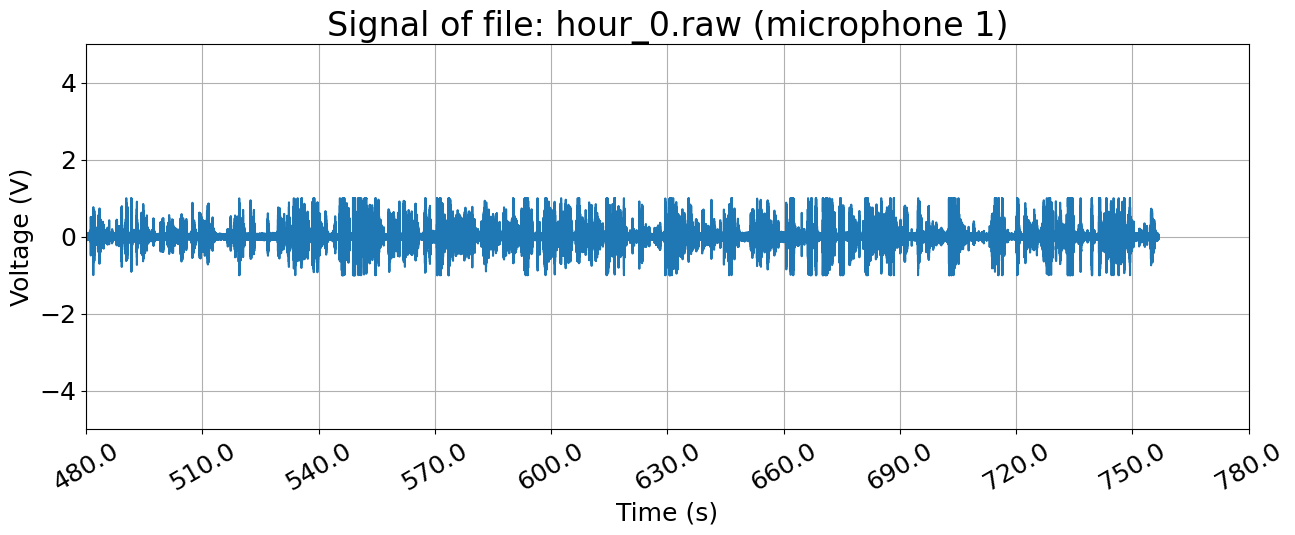

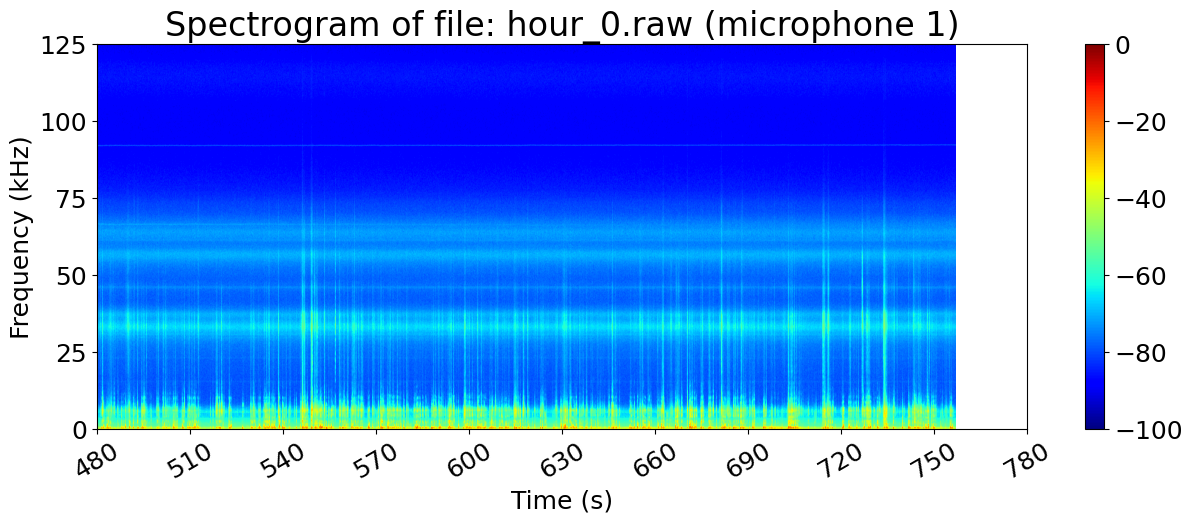

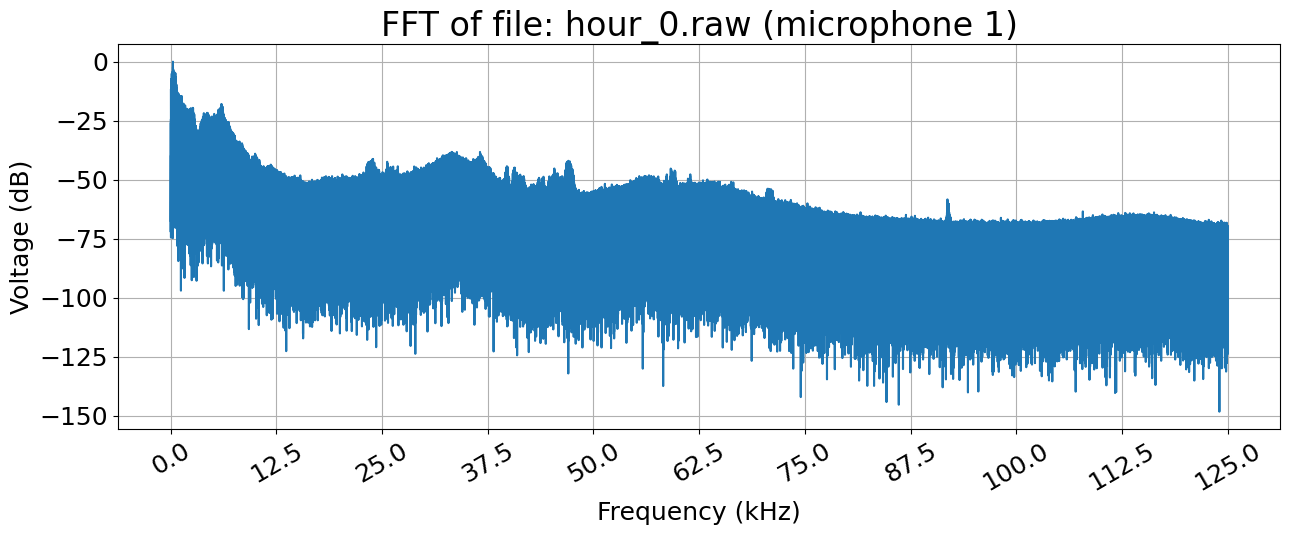

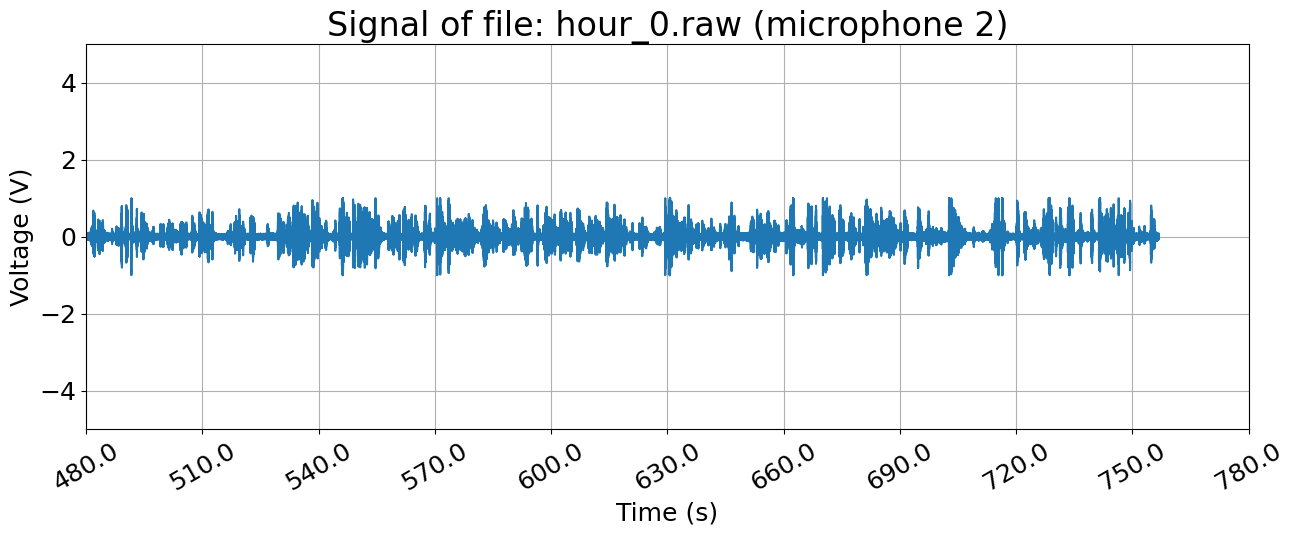

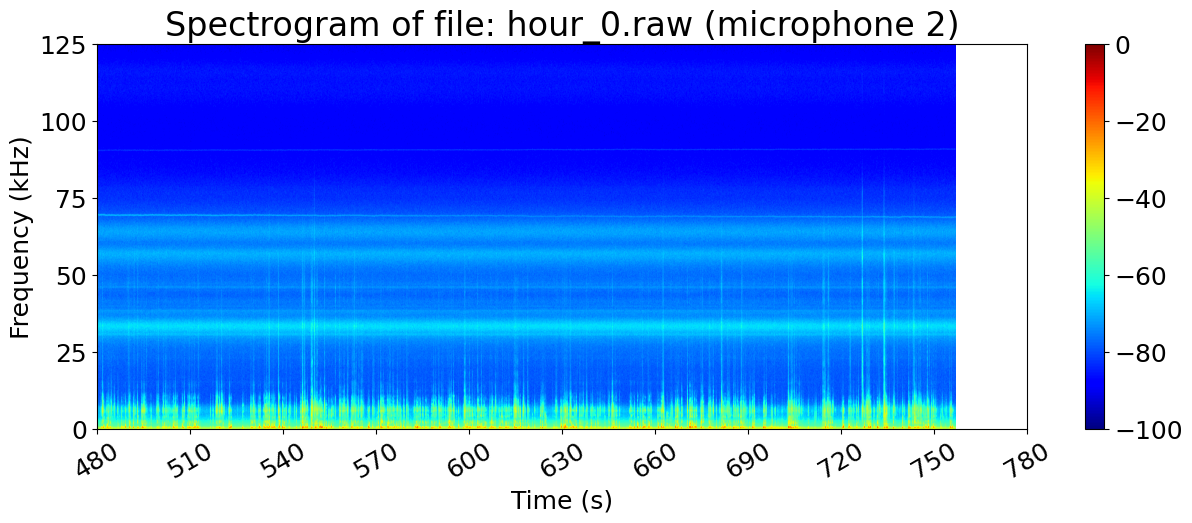

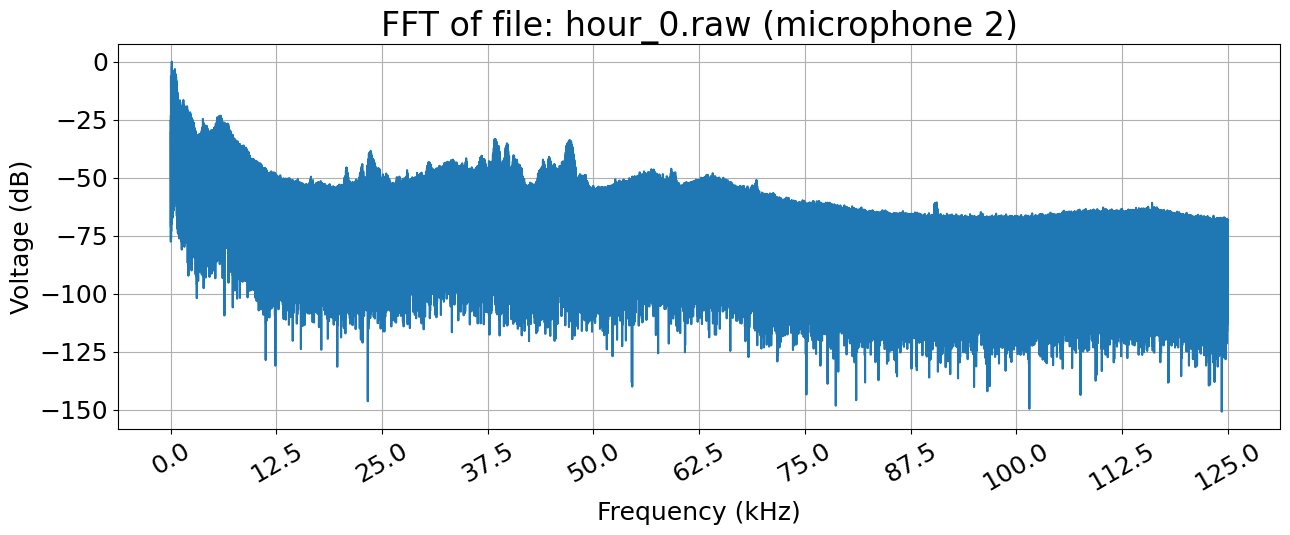

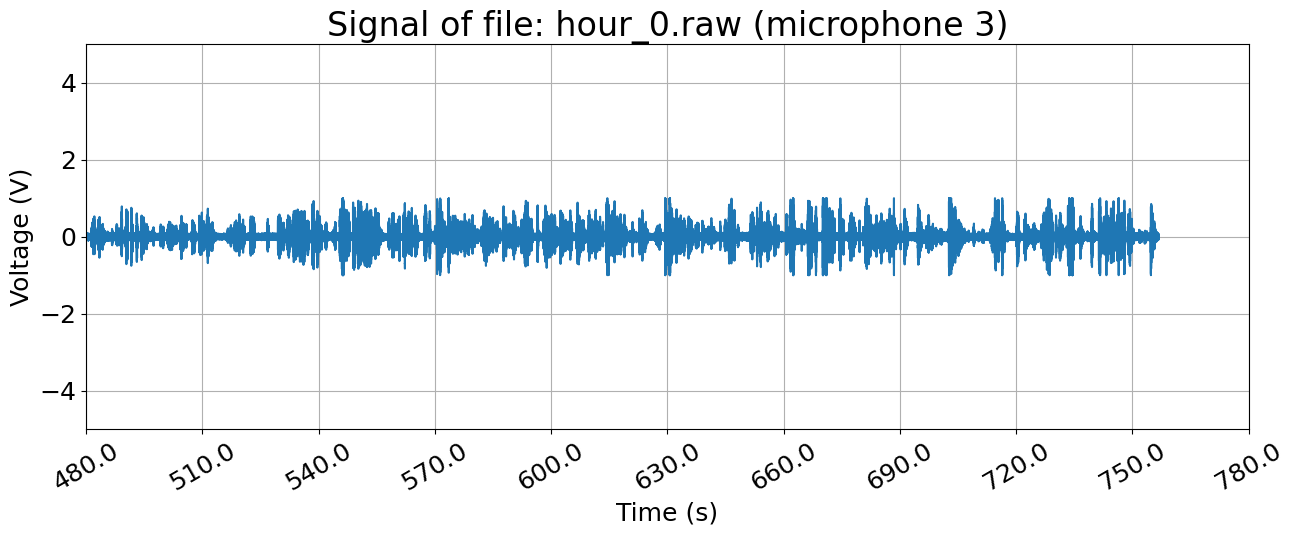

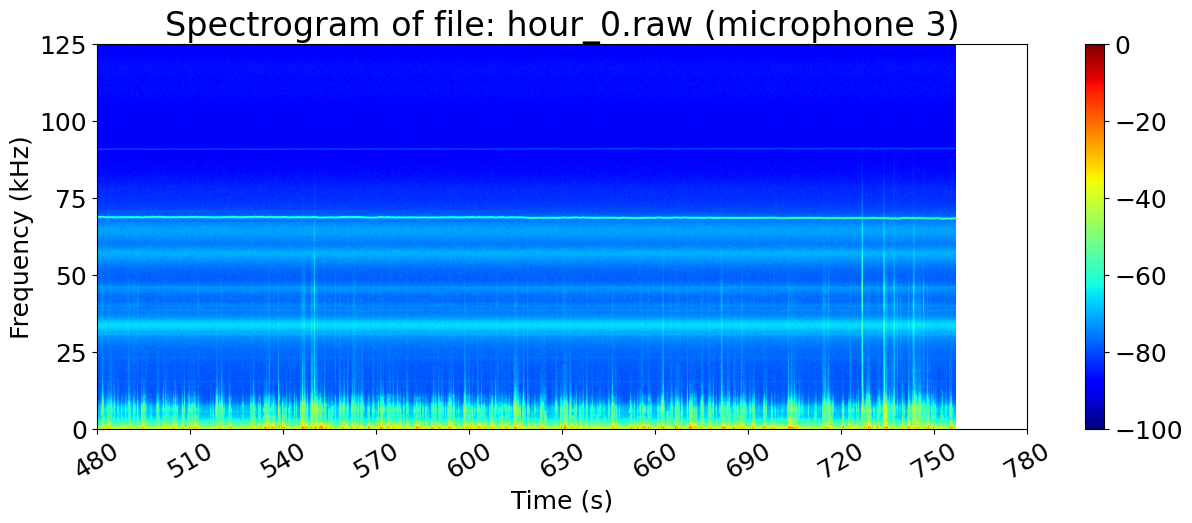

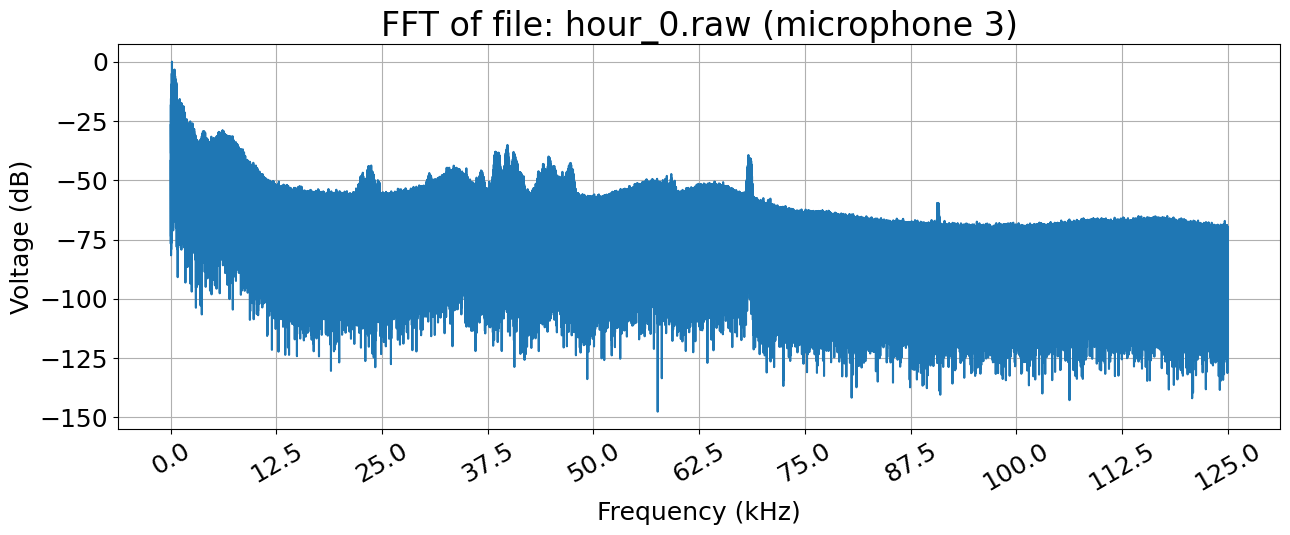

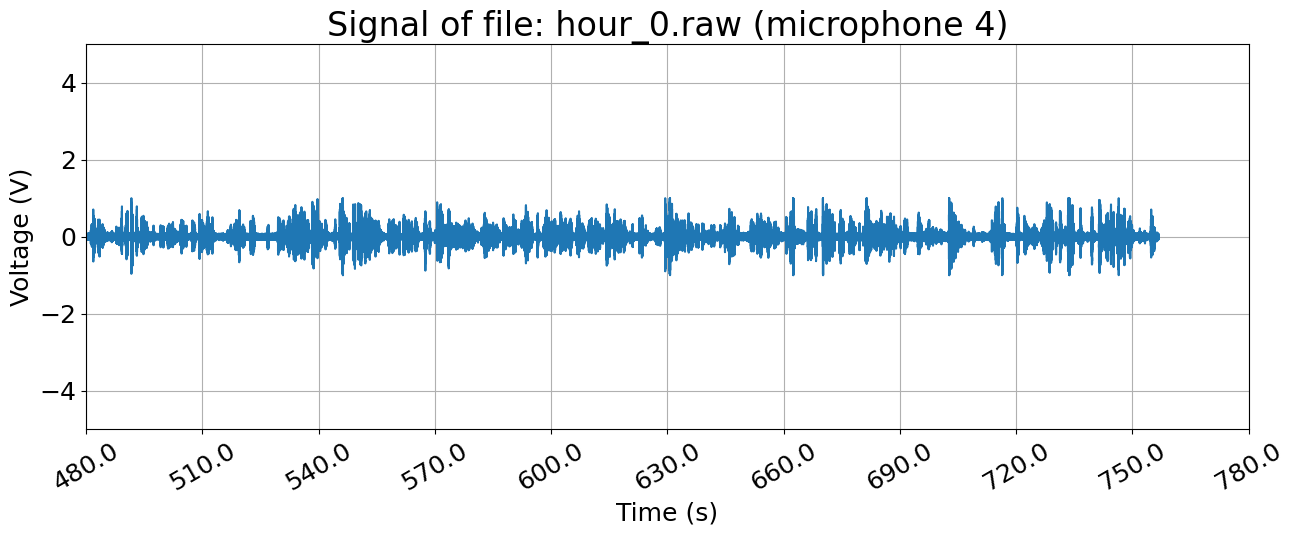

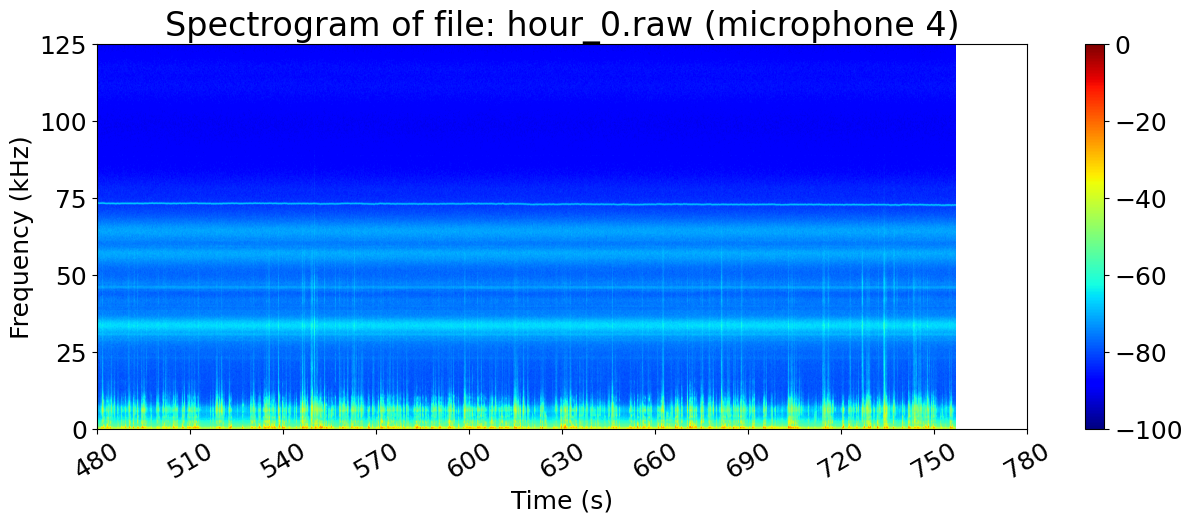

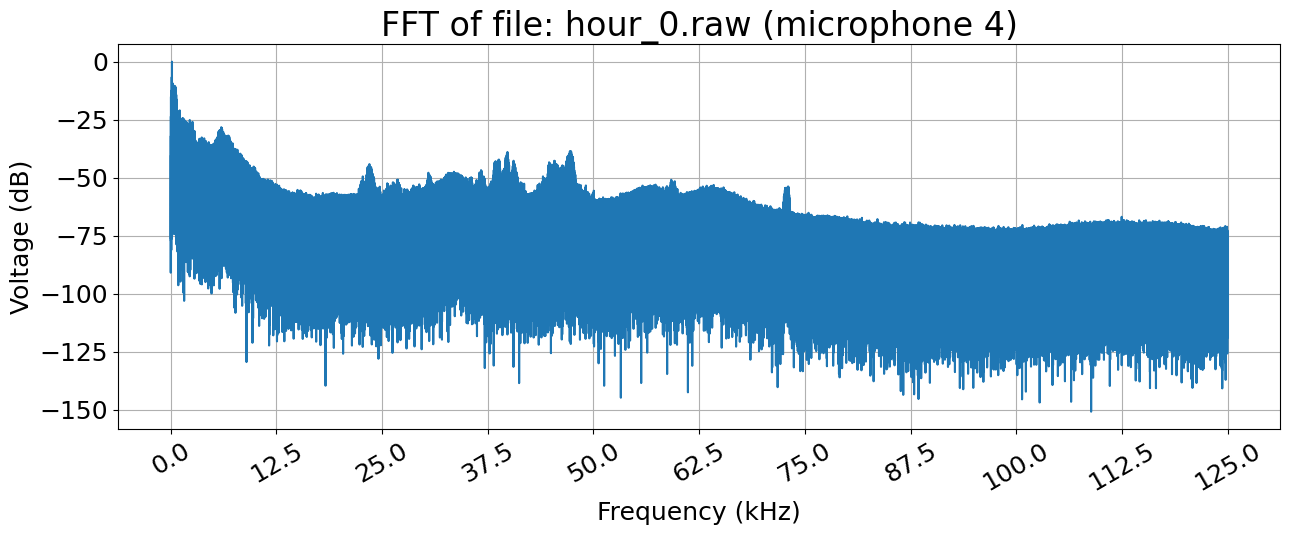

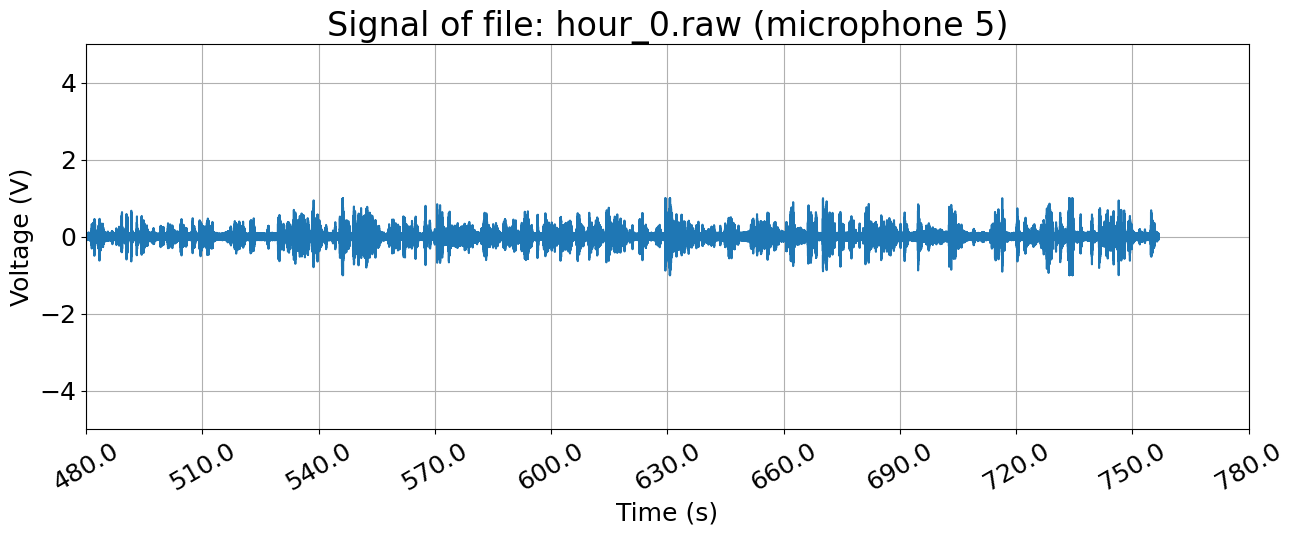

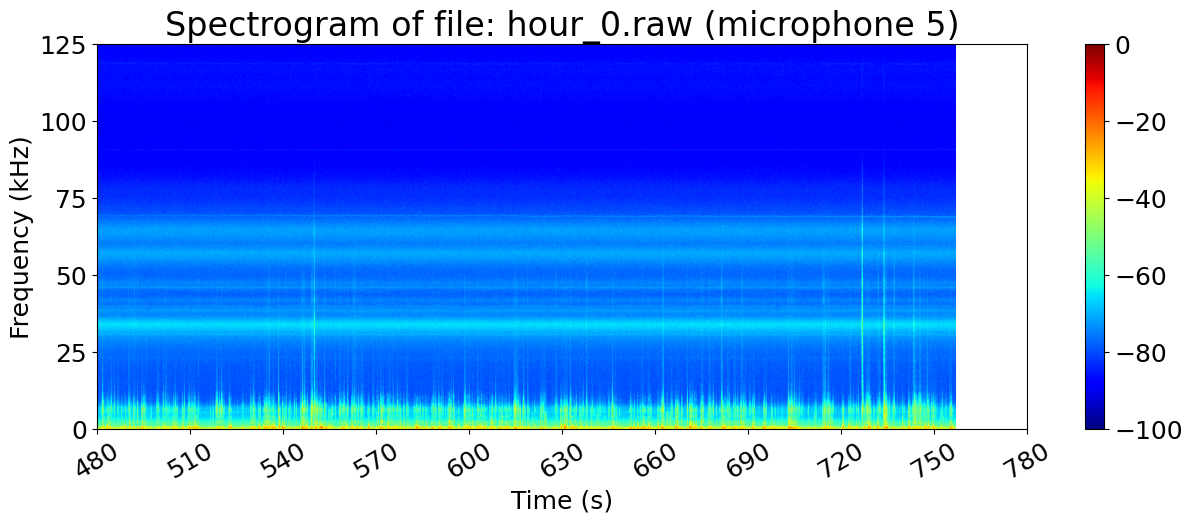

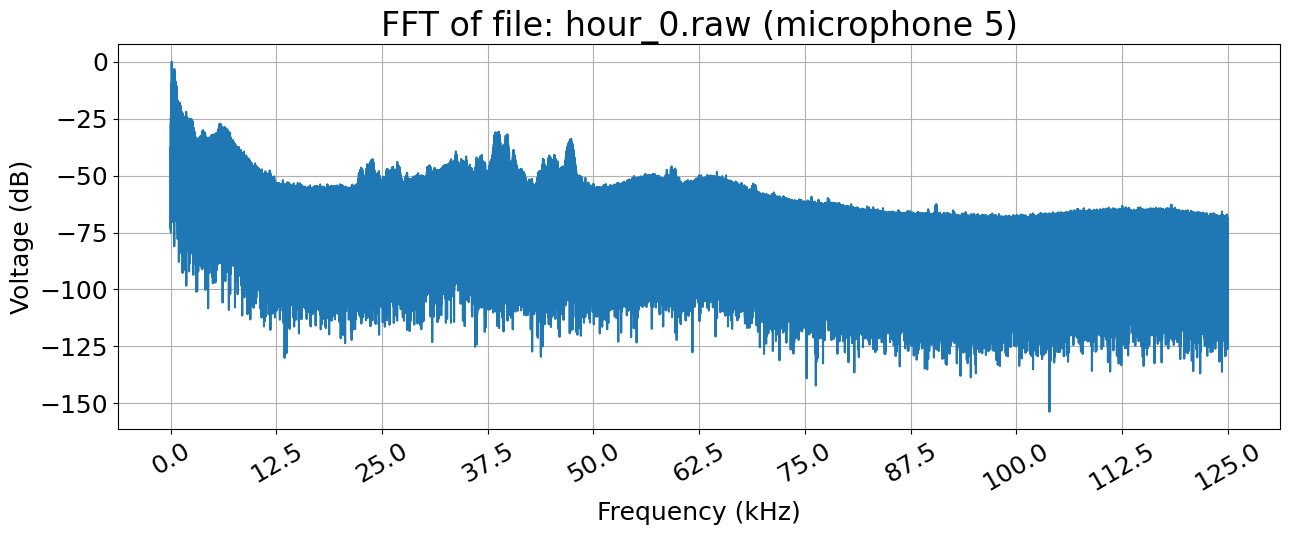

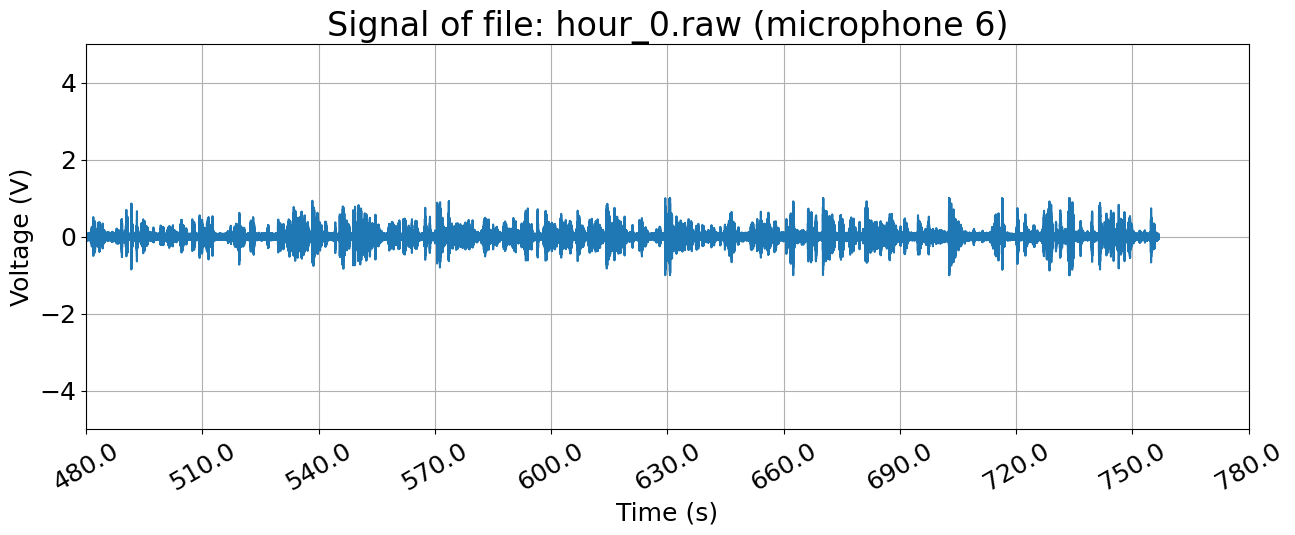

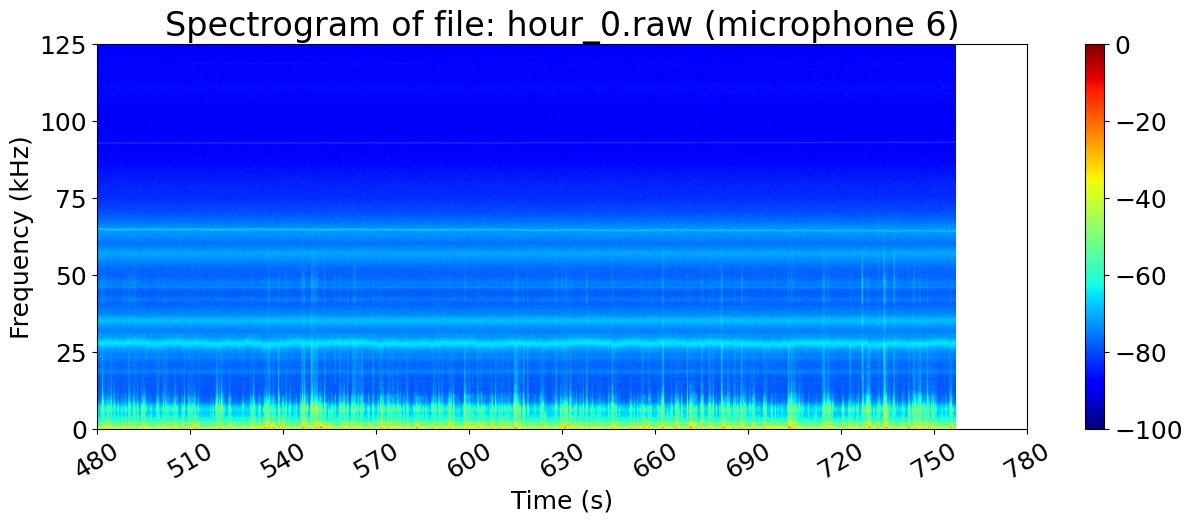

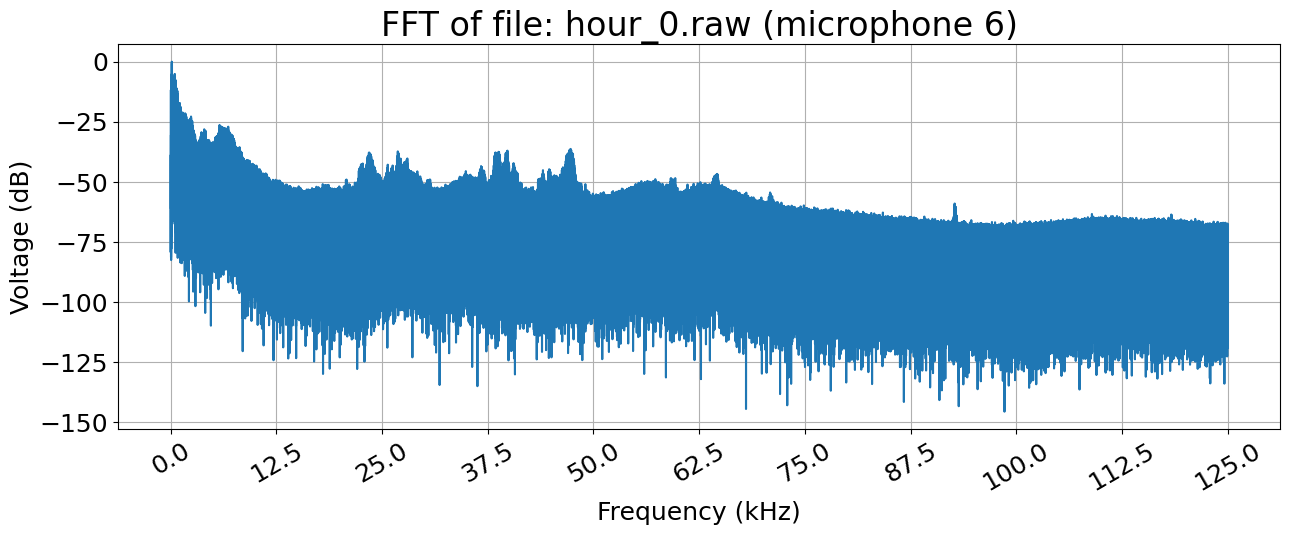

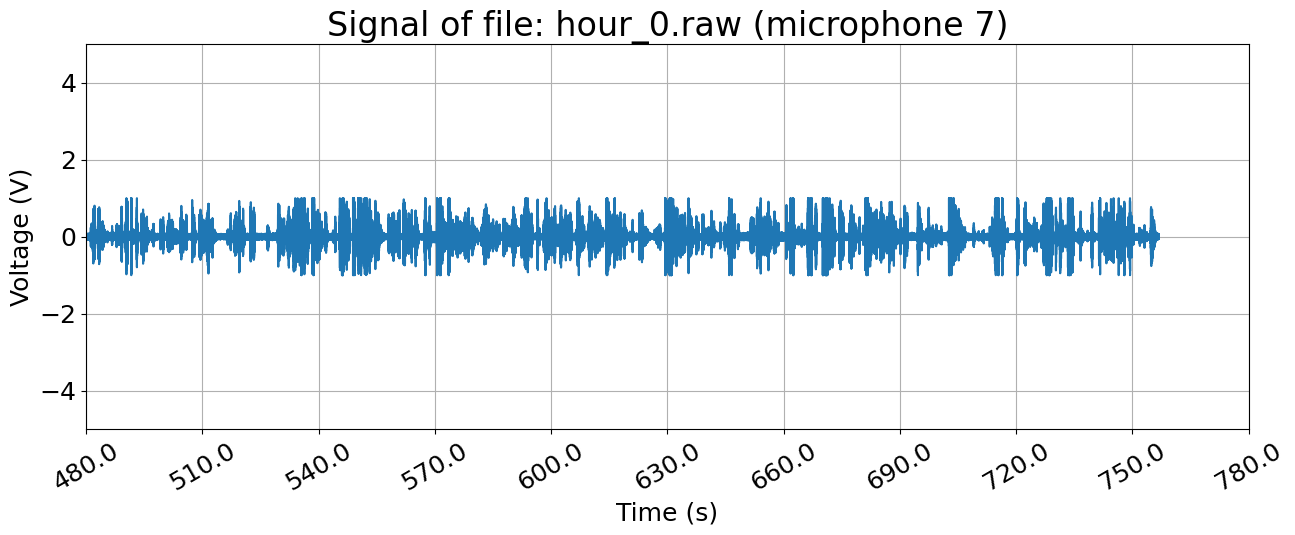

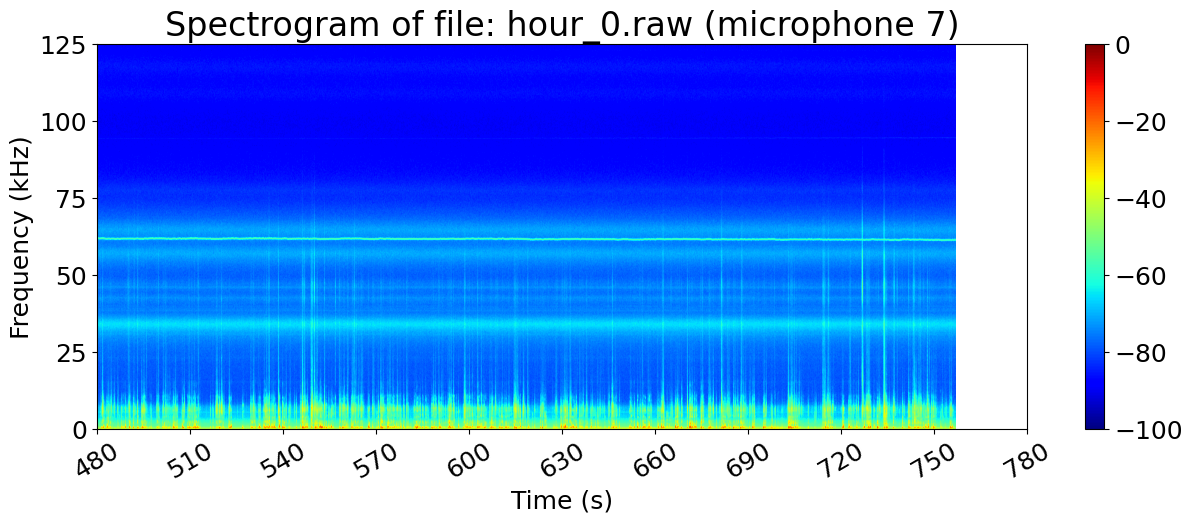

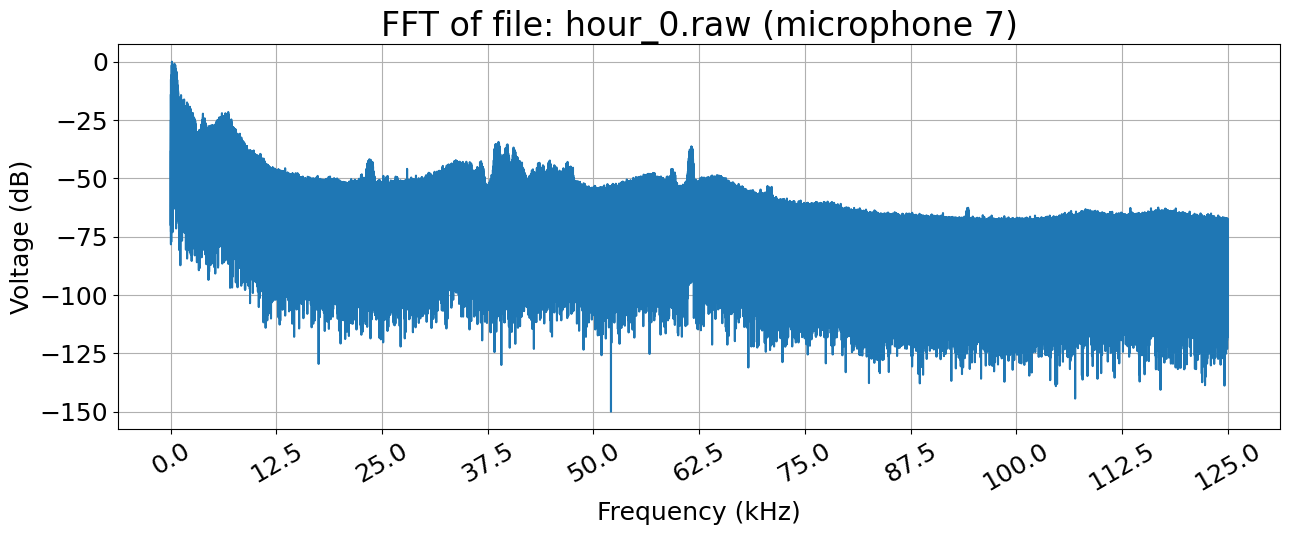

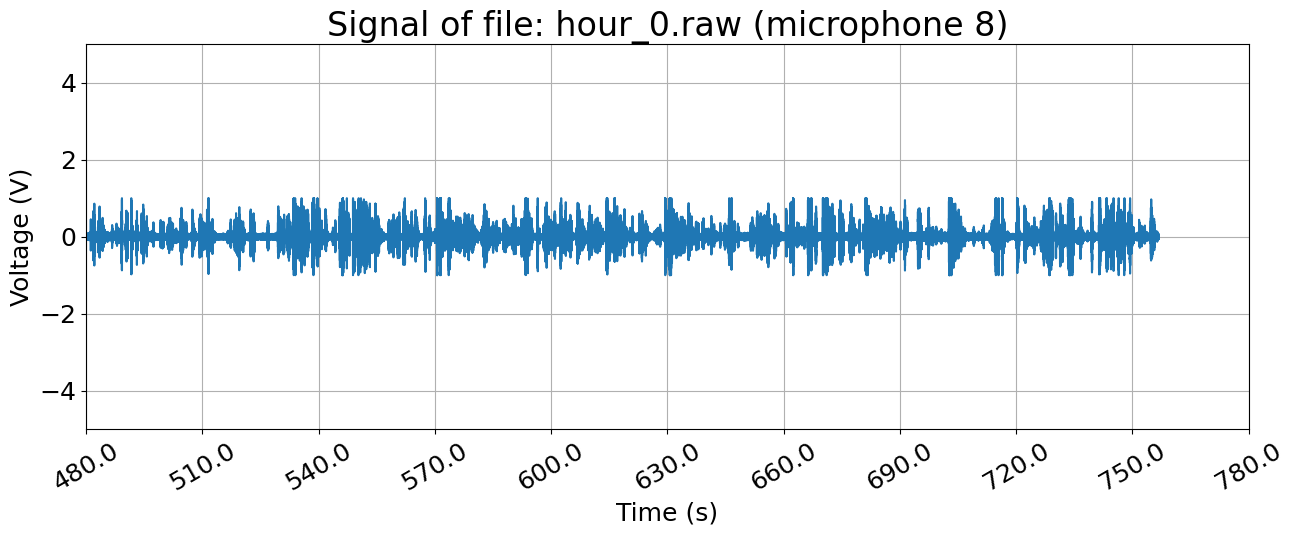

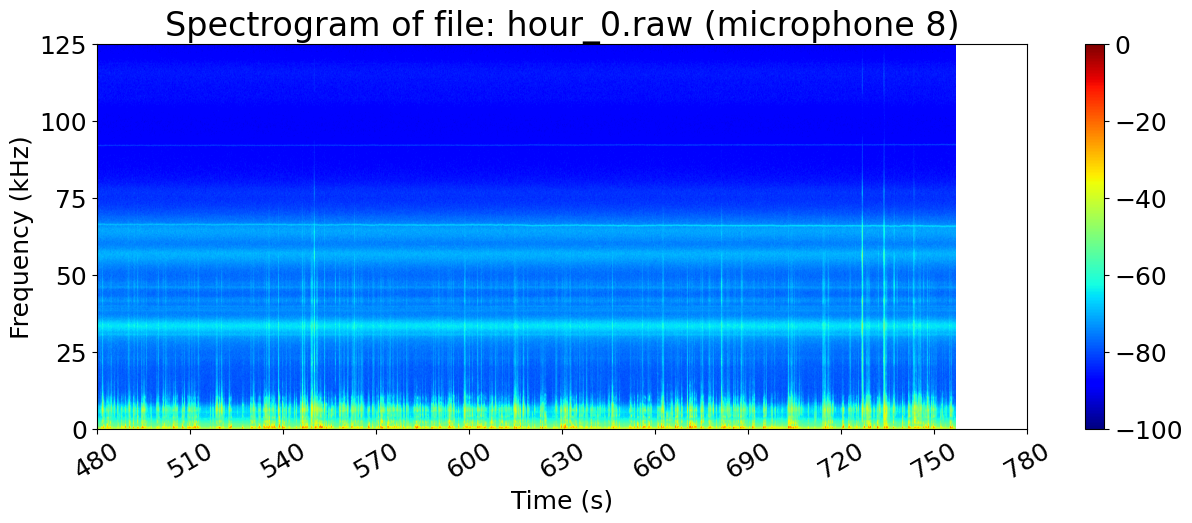

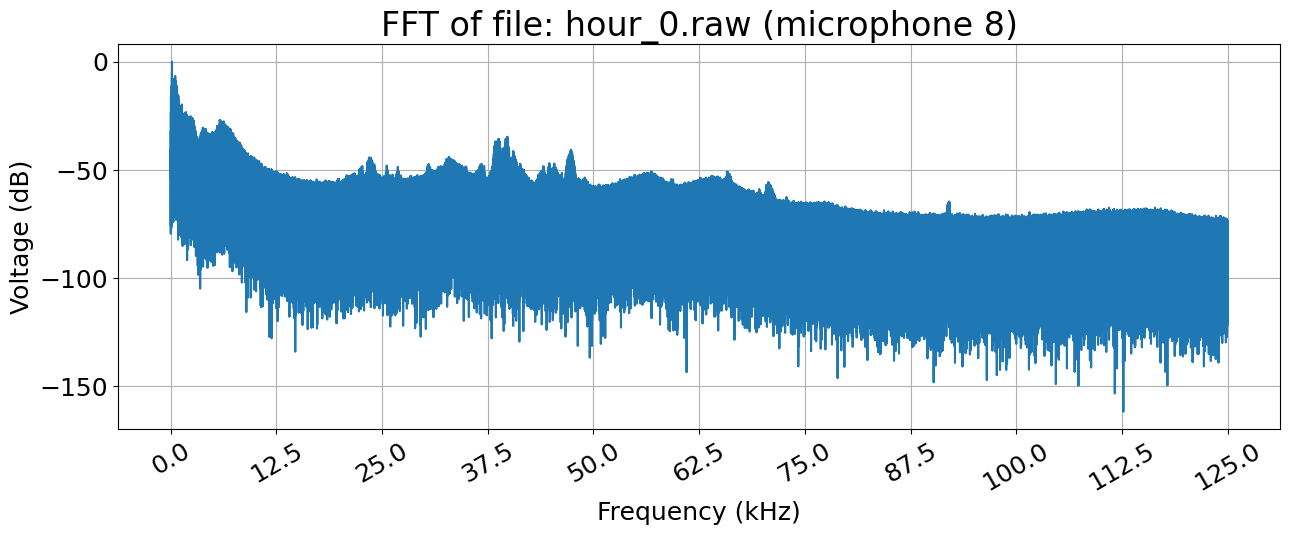

In [9]:
read_offset = 480
read_duration_in_secs = 300
print('Start')
write_dir = Path(f'/Volumes/Elements/UBNA_array_tests2025/mic_array_test_20250422/inHHlab/{FILEPATH.stem}_offset{int(WRITE_OFFSET)}')
write_file = write_dir / f'{FILEPATH.stem}_ALLchannels_offset{int(WRITE_OFFSET)}.WAV'
print(f'Plotting data from {write_file}')

recorded_audio = sf.SoundFile(write_file)
recorded_audio.seek(int(SAMPLERATE*read_offset))
audio_seg = recorded_audio.read(int(SAMPLERATE*read_duration_in_secs))
for selected_channel in np.arange(0, 8, 1).astype(int):
    channel_audio_seg = audio_seg[:,selected_channel]

    vmax = 0
    vmin = -100

    audio_features = dict()
    audio_features['file_path'] = FILEPATH
    audio_features['audio_seg'] = channel_audio_seg
    audio_features['sample_rate'] = SAMPLERATE
    audio_features['start'] = read_offset
    audio_features['duration'] = read_duration_in_secs

    spec_features = dict()
    spec_features['NFFT'] = 1024 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
    spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
    spec_features['vmin'] = vmin
    spec_features['vmax'] = vmax

    audio_features['plot_title'] = f"file: {audio_features['file_path'].name} (microphone {selected_channel+1})"
    plot_audio_seg_signal(audio_features)
    plot_audio_seg_spec(audio_features, spec_features)
    plot_audio_seg_fft(audio_features)